In [1]:
"""
example_gene_pair.py
====================
Visualize a specific significant dGCNA edge:
1. Per-donor correlation values, colored by disease condition
2. Scatterplots of expression and residuals for the largest donor
3. Subsampling stability: correlation range as we remove cells from the largest donor

Assumes in memory:
  - edge_df: with columns gene1, gene2, delta_r, abs_delta_r, r_t2d, r_ctrl
  - residuals_df: pd.DataFrame (cells x genes) LMM residuals
  - obs_df: pd.DataFrame with 'Donor', 'Disease' columns (same index as residuals_df)
  - adata: AnnData with expression values (log2(RPKM+1))
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr
from tqdm import tqdm
import scanpy as sc

In [2]:
adata=sc.read_loom('Integrated_betas.loom') 
adata.obs_names=adata.obs.obs_names
adata.var_names=adata.var.gene_name

C:\Users\Leo\anaconda3\Lib\functools.py:934: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
C:\Users\Leo\anaconda3\Lib\functools.py:934: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


In [3]:
edge_df=pd.read_csv('Edges_data.csv', index_col=0)

In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# 1. Pick an example gene pair (significant, large |Δr|, illustrative)
# ─────────────────────────────────────────────────────────────────────────────

# Choose a pair with high |Δr| — pick from top 5% of significant edges
sig_edges = edge_df[edge_df['abs_delta_r'] > 0].sort_values('abs_delta_r', ascending=False).reset_index()
print("Top 10 significant edges by |Δr|:")
print(sig_edges[['gene1', 'gene2', 'r_ctrl', 'r_t2d', 'delta_r', 'abs_delta_r']].head(10))

# Select the top edge (or change idx to pick another)
idx = 0
gene_a = sig_edges.iloc[idx]['gene1']
gene_b = sig_edges.iloc[idx]['gene2']

gene_a = 'CEBPG'
gene_b = 'ARL15'

idx = sig_edges.index[(sig_edges["gene1"] == gene_a) & (sig_edges["gene2"] == gene_b)].values[0]

print(f"\nSelected pair: {gene_a} — {gene_b}")
print(f"  r_ctrl = {sig_edges.iloc[idx]['r_ctrl']:.3f}")
print(f"  r_t2d  = {sig_edges.iloc[idx]['r_t2d']:.3f}")
print(f"  Δr     = {sig_edges.iloc[idx]['delta_r']:.3f}")

Top 10 significant edges by |Δr|:
     gene1   gene2    r_ctrl     r_t2d   delta_r  abs_delta_r
0     DSTN  MALAT1 -0.288737  0.381721  0.670458     0.670458
1  GABARAP  MALAT1 -0.179432  0.465629  0.645061     0.645061
2     UBL5  MALAT1 -0.262128  0.316086  0.578213     0.578213
3    RPLP0  MALAT1 -0.283841  0.289827  0.573668     0.573668
4   RPL35A  MALAT1 -0.178356  0.386339  0.564695     0.564695
5     OAZ1  MALAT1 -0.248164  0.303845  0.552009     0.552009
6  GABARAP  ATRAID  0.013054  0.549886  0.536833     0.536833
7    RPL36  MALAT1 -0.195924  0.332806  0.528730     0.528730
8    COX8A  MALAT1 -0.200166  0.303653  0.503820     0.503820
9    RPS14  MALAT1 -0.194800  0.308590  0.503390     0.503390

Selected pair: CEBPG — ARL15
  r_ctrl = -0.178
  r_t2d  = 0.053
  Δr     = 0.231


In [5]:
sig_edges[(sig_edges["gene1"] == gene_a) & (sig_edges["gene2"] == gene_b)]

,index,gene1,gene2,r_t2d,r_ctrl,delta_r,abs_delta_r,max_logFC,min_logFC,mean_logFC
2998,74962,CEBPG,ARL15,0.052818,-0.178373,0.231191,0.231191,0.884792,0.849483,0.867138


In [6]:
sig_edges[(sig_edges["gene1"] == gene_a)].sort_values('abs_delta_r')

,index,gene1,gene2,r_t2d,r_ctrl,delta_r,abs_delta_r,max_logFC,min_logFC,mean_logFC
24177,74658,CEBPG,PFKL,-0.029224,-0.121715,0.092491,0.092491,0.849483,0.065097,0.457290
24088,75119,CEBPG,MRPL48,-0.062077,0.032459,-0.094535,0.094535,0.849483,0.168102,0.508793
23220,74741,CEBPG,SENP7,-0.071428,0.036967,-0.108395,0.108395,0.849483,0.663256,0.756370
22769,74665,CEBPG,PREP,0.060937,-0.051961,0.112897,0.112897,0.849483,0.241182,0.545333
21674,74661,CEBPG,APCDD1L-AS1,-0.049470,-0.171516,0.122046,0.122046,0.849483,0.002220,0.425851
21623,74987,CEBPG,DDR1,-0.136978,-0.259327,0.122349,0.122349,0.849483,0.024125,0.436804
21571,74840,CEBPG,S100A11,-0.029167,-0.151856,0.122689,0.122689,0.849483,0.240907,0.545195
21288,74631,CEBPG,ARHGEF10L,0.046451,-0.078066,0.124518,0.124518,0.849483,0.002820,0.426152
21067,74676,CEBPG,OBSL1,-0.030151,-0.155960,0.125809,0.125809,0.849483,0.092251,0.470867
20020,74766,CEBPG,DYNC1LI1,0.160227,0.028241,0.131986,0.131986,0.849483,0.173485,0.511484


In [8]:
from run_dgcna_correlation import get_lmm_residuals
 
residuals_df, obs_df = get_lmm_residuals(adata, min_cells_per_donor=30)

Kept 17 donors with > 30 cells
Cells: 1038, donors: 17, genes: 12727


In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# 2. Per-donor correlations
# ─────────────────────────────────────────────────────────────────────────────

donors = obs_df['Donor'].unique()
donor_corrs = []

for donor in donors:
    mask = obs_df['Donor'] == donor
    n_cells = mask.sum()
    if n_cells < 10:
        continue
    disease = obs_df.loc[mask, 'Disease'].iloc[0]
    
    # Correlation on residuals
    x = residuals_df.loc[mask, gene_a].values
    y = residuals_df.loc[mask, gene_b].values
    r, p = pearsonr(x, y)
    
    donor_corrs.append({
        'Donor': donor, 'Disease': disease, 'r': r, 'p': p, 'n_cells': n_cells
    })

donor_corr_df = pd.DataFrame(donor_corrs).sort_values('Disease')
print("\nPer-donor correlations:")
print(donor_corr_df.to_string(index=False))


Per-donor correlations:
       Donor Disease         r        p  n_cells
   Sample110     T2D  0.257318 0.009752      100
HP1711701T2D     T2D  0.174488 0.230486       49
HP1606401T2D     T2D  0.032050 0.814605       56
HP1605601T2D     T2D -0.036246 0.841282       33
HP1602301T2D     T2D -0.102729 0.306655      101
HP1601201T2D     T2D  0.044402 0.769517       46
HP1529801T2D     T2D -0.057298 0.615969       79
   Sample109     T2D -0.117853 0.310618       76
   Sample108     T2D  0.071646 0.652071       42
   Sample104  normal -0.326149 0.026963       46
   HP1714601  normal -0.012913 0.933700       44
   Sample105  normal -0.162811 0.195037       65
   Sample103  normal -0.260444 0.026055       73
   HP1711001  normal  0.062278 0.714232       37
   Sample102  normal -0.140344 0.325962       51
   Sample106  normal -0.202330 0.117870       61
   HP1525901  normal -0.115227 0.311917       79


In [10]:
donor_corr_df[['r','Disease']].groupby('Disease').max()-donor_corr_df[['r','Disease']].groupby('Disease').min()

,r
Disease,
T2D,0.375171
normal,0.388428


In [11]:
donor_corr_df[['r','Disease']].groupby('Disease').std()

,r
Disease,
T2D,0.125490
normal,0.125962


In [12]:
# ─────────────────────────────────────────────────────────────────────────────
# 3. Identify largest ctrl and largest T2D donor
# ─────────────────────────────────────────────────────────────────────────────

def _is_t2d(d):
    return ('T2D' in str(d)) or ('diabetes' in str(d).lower())

ctrl_donors_df = donor_corr_df[~donor_corr_df['Disease'].apply(_is_t2d)]
t2d_donors_df = donor_corr_df[donor_corr_df['Disease'].apply(_is_t2d)]

largest_ctrl_donor = ctrl_donors_df.sort_values('r', ascending=True).iloc[0]['Donor']
largest_ctrl_n = int(ctrl_donors_df.loc[ctrl_donors_df['Donor'] == largest_ctrl_donor, 'n_cells'].iloc[0])

largest_t2d_donor = t2d_donors_df.sort_values('r', ascending=False).iloc[0]['Donor']
largest_t2d_n = int(t2d_donors_df.loc[t2d_donors_df['Donor'] == largest_t2d_donor, 'n_cells'].iloc[0])

print(f"\nLargest ctrl donor: {largest_ctrl_donor}, {largest_ctrl_n} cells")
print(f"Largest T2D donor:  {largest_t2d_donor}, {largest_t2d_n} cells")


Largest ctrl donor: Sample104, 46 cells
Largest T2D donor:  Sample110, 100 cells


In [13]:

# ─────────────────────────────────────────────────────────────────────────────
# 4. Subsampling within each representative donor
# ─────────────────────────────────────────────────────────────────────────────

fractions = [1.0, 0.95, 0.90, 0.85, 0.80, 0.75, 0.70, 0.65, 0.60, 0.55, 0.50]
n_iter = 1000
rng = np.random.default_rng(42)

def subsample_donor(donor_name, n_donor):
    mask_d = obs_df['Donor'] == donor_name
    xd = residuals_df.loc[mask_d, gene_a].values
    yd = residuals_df.loc[mask_d, gene_b].values
    nd = len(xd)
    results = []
    for frac in fractions:
        n_sample = int(nd * frac)
        rs = []
        for _ in range(n_iter):
            if frac == 1.0:
                rs.append(pearsonr(xd, yd)[0])
                break
            idx_sub = rng.choice(nd, size=n_sample, replace=False)
            rs.append(pearsonr(xd[idx_sub], yd[idx_sub])[0])
        results.append({
            'frac': frac, 'n_cells': n_sample,
            'mean_r': np.mean(rs), 'sd_r': np.std(rs),
            'q025': np.percentile(rs, 2.5), 'q975': np.percentile(rs, 97.5),
        })
    return pd.DataFrame(results), xd, yd

sub_ctrl_df, x_ctrl_donor, y_ctrl_donor = subsample_donor(largest_ctrl_donor, largest_ctrl_n)
sub_t2d_df, x_t2d_donor, y_t2d_donor = subsample_donor(largest_t2d_donor, largest_t2d_n)

print("\nSubsampling results (ctrl donor):")
print(sub_ctrl_df[['frac', 'n_cells', 'mean_r', 'sd_r', 'q025', 'q975']].to_string(index=False))
print("\nSubsampling results (T2D donor):")
print(sub_t2d_df[['frac', 'n_cells', 'mean_r', 'sd_r', 'q025', 'q975']].to_string(index=False))



Subsampling results (ctrl donor):
 frac  n_cells    mean_r     sd_r      q025      q975
 1.00       46 -0.326149 0.000000 -0.326149 -0.326149
 0.95       43 -0.325340 0.032122 -0.402771 -0.266718
 0.90       41 -0.325888 0.042744 -0.416392 -0.247472
 0.85       39 -0.323330 0.052886 -0.433865 -0.230702
 0.80       36 -0.325805 0.066740 -0.460049 -0.203552
 0.75       34 -0.325416 0.072345 -0.469617 -0.185474
 0.70       32 -0.324657 0.084797 -0.492229 -0.154901
 0.65       29 -0.327638 0.098019 -0.512645 -0.141156
 0.60       27 -0.326579 0.101302 -0.519501 -0.115095
 0.55       25 -0.329272 0.118109 -0.548694 -0.080510
 0.50       23 -0.328852 0.131893 -0.574344 -0.053291

Subsampling results (T2D donor):
 frac  n_cells   mean_r     sd_r     q025     q975
 1.00      100 0.257318 0.000000 0.257318 0.257318
 0.95       95 0.256922 0.023880 0.215316 0.306058
 0.90       90 0.256138 0.035240 0.191459 0.326685
 0.85       85 0.258802 0.043711 0.175387 0.345710
 0.80       80 0.258294 0.05

In [14]:
-0.411294 - -0.242223

-0.169071

In [15]:
0.326756-0.19162

0.13513599999999998

In [16]:

# ─────────────────────────────────────────────────────────────────────────────
# 5. Pooled cell subsampling stability
#    Subsample % of cells from each condition (pooled across donors)
#    and recompute correlation. Like panel C but for pooled groups.
# ─────────────────────────────────────────────────────────────────────────────

def is_t2d(d):
    return ('T2D' in str(d)) or ('diabetes' in str(d).lower())

mask_ctrl_all = ~obs_df['Disease'].apply(is_t2d)
mask_t2d_all = obs_df['Disease'].apply(is_t2d)

x_ctrl_all = residuals_df.loc[mask_ctrl_all, gene_a].values
y_ctrl_all = residuals_df.loc[mask_ctrl_all, gene_b].values
x_t2d_all = residuals_df.loc[mask_t2d_all, gene_a].values
y_t2d_all = residuals_df.loc[mask_t2d_all, gene_b].values

print(f"\nPooled ctrl cells: {len(x_ctrl_all)}, T2D cells: {len(x_t2d_all)}")

pooled_fracs = [1.0, 0.95, 0.90, 0.85, 0.80, 0.75, 0.70, 0.65, 0.60, 0.55, 0.50]
n_iter_pooled = 1000
rng_pooled = np.random.default_rng(123)

pooled_sub_results = []
for frac in pooled_fracs:
    n_ctrl_sample = int(len(x_ctrl_all) * frac)
    n_t2d_sample = int(len(x_t2d_all) * frac)
    
    for _ in range(n_iter_pooled):
        if frac == 1.0:
            r_c = pearsonr(x_ctrl_all, y_ctrl_all)[0]
            r_t = pearsonr(x_t2d_all, y_t2d_all)[0]
            pooled_sub_results.append({
                'frac': frac, 'r_ctrl': r_c, 'r_t2d': r_t, 'delta_r': r_t - r_c
            })
            break
        
        idx_c = rng_pooled.choice(len(x_ctrl_all), size=n_ctrl_sample, replace=False)
        idx_t = rng_pooled.choice(len(x_t2d_all), size=n_t2d_sample, replace=False)
        
        r_c = pearsonr(x_ctrl_all[idx_c], y_ctrl_all[idx_c])[0]
        r_t = pearsonr(x_t2d_all[idx_t], y_t2d_all[idx_t])[0]
        
        pooled_sub_results.append({
            'frac': frac, 'r_ctrl': r_c, 'r_t2d': r_t, 'delta_r': r_t - r_c
        })

pooled_sub_df = pd.DataFrame(pooled_sub_results)
print("\nPooled cell subsampling stability:")
for frac_val in pooled_fracs:
    subset = pooled_sub_df[pooled_sub_df['frac'] == frac_val]
    print(f"  {frac_val*100:.0f}%: r_ctrl = {subset['r_ctrl'].mean():.3f} ± {subset['r_ctrl'].std():.3f}, "
          f"r_t2d = {subset['r_t2d'].mean():.3f} ± {subset['r_t2d'].std():.3f}, "
          f"Δr = {subset['delta_r'].mean():.3f} ± {subset['delta_r'].std():.3f}")



Pooled ctrl cells: 456, T2D cells: 582

Pooled cell subsampling stability:
  100%: r_ctrl = -0.178 ± nan, r_t2d = 0.053 ± nan, Δr = 0.231 ± nan
  95%: r_ctrl = -0.178 ± 0.011, r_t2d = 0.053 ± 0.011, Δr = 0.231 ± 0.015
  90%: r_ctrl = -0.179 ± 0.016, r_t2d = 0.053 ± 0.015, Δr = 0.232 ± 0.021
  85%: r_ctrl = -0.178 ± 0.020, r_t2d = 0.053 ± 0.019, Δr = 0.231 ± 0.027
  80%: r_ctrl = -0.179 ± 0.023, r_t2d = 0.053 ± 0.022, Δr = 0.232 ± 0.033
  75%: r_ctrl = -0.179 ± 0.028, r_t2d = 0.054 ± 0.026, Δr = 0.233 ± 0.038
  70%: r_ctrl = -0.178 ± 0.031, r_t2d = 0.053 ± 0.030, Δr = 0.231 ± 0.045
  65%: r_ctrl = -0.178 ± 0.034, r_t2d = 0.053 ± 0.033, Δr = 0.231 ± 0.048
  60%: r_ctrl = -0.178 ± 0.040, r_t2d = 0.051 ± 0.037, Δr = 0.228 ± 0.055
  55%: r_ctrl = -0.177 ± 0.043, r_t2d = 0.052 ± 0.040, Δr = 0.229 ± 0.059
  50%: r_ctrl = -0.177 ± 0.047, r_t2d = 0.054 ± 0.044, Δr = 0.231 ± 0.063


In [18]:
def _get_expr(donor_name, gene):
    mask = adata.obs['Donor'] == donor_name
    X = adata[mask, gene].X
    return X.toarray().flatten() if hasattr(X, 'toarray') else X.flatten()

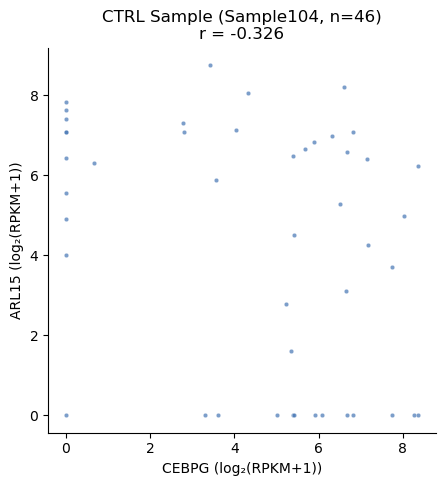

In [25]:
# A: Expression (ctrl donor)

# CV for dGCNA significant vs non-significant
fig, ax = plt.subplots(figsize=(5, 5))

expr_a_ctrl = _get_expr(largest_ctrl_donor, gene_a)
expr_b_ctrl = _get_expr(largest_ctrl_donor, gene_b)
r_expr_ctrl, _ = pearsonr(expr_a_ctrl, expr_b_ctrl)
sns.scatterplot(x=expr_a_ctrl, y=expr_b_ctrl, alpha=0.7, s=10, color='#4575b4')
ax.set_xlabel(f'{gene_a} (log₂(RPKM+1))')
ax.set_ylabel(f'{gene_b} (log₂(RPKM+1))')
ax.set_title(f'CTRL Sample ({largest_ctrl_donor}, n={largest_ctrl_n})\nr = {r_expr_ctrl:.3f}')
ax.spines[['top', 'right']].set_visible(False)

plt.savefig('Figure2/ctrl_expr.png', dpi=200, bbox_inches='tight')
plt.savefig('Figure2/ctrl_expr.svg', bbox_inches='tight')

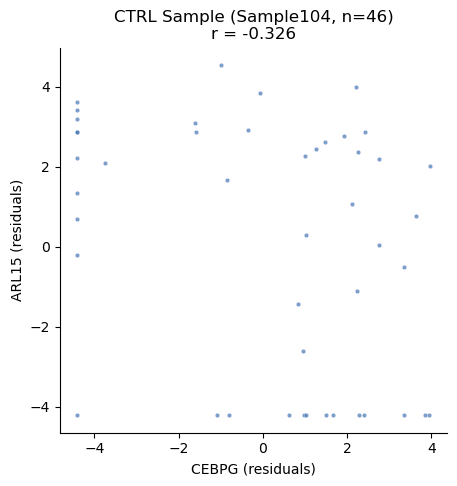

In [27]:
# B: Residuals (ctrl donor)
# CV for dGCNA significant vs non-significant
fig, ax = plt.subplots(figsize=(5, 5))

r_resid_ctrl, _ = pearsonr(x_ctrl_donor, y_ctrl_donor)

sns.scatterplot(x=x_ctrl_donor, y=y_ctrl_donor, alpha=0.7, s=10, color='#4575b4')
ax.set_xlabel(f'{gene_a} (residuals)')
ax.set_ylabel(f'{gene_b} (residuals)')
ax.set_title(f'CTRL Sample ({largest_ctrl_donor}, n={largest_ctrl_n})\nr = {r_resid_ctrl:.3f}')
ax.spines[['top', 'right']].set_visible(False)

plt.savefig('Figure2/ctrl_residuals.png', dpi=200, bbox_inches='tight')
plt.savefig('Figure2/ctrl_residuals.svg', bbox_inches='tight')

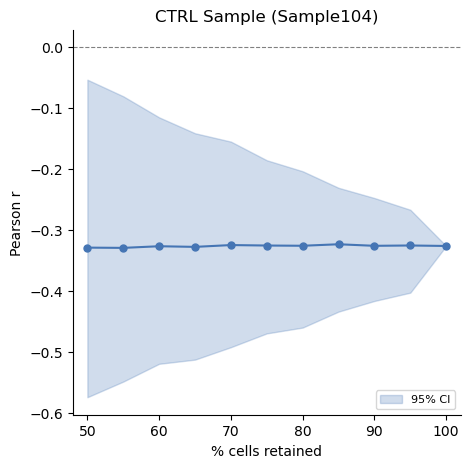

In [28]:
# C: Subsampling (ctrl donor)
fig, ax = plt.subplots(figsize=(5, 5))
ax.fill_between(sub_ctrl_df['frac'] * 100, sub_ctrl_df['q025'], sub_ctrl_df['q975'],
                alpha=0.25, color='#4575b4', label='95% CI')
ax.plot(sub_ctrl_df['frac'] * 100, sub_ctrl_df['mean_r'], 'o-', color='#4575b4', markersize=5)
ax.axhline(0, color='gray', lw=0.8, ls='--')
ax.set_xlabel('% cells retained')
ax.set_ylabel('Pearson r')
ax.set_title(f'CTRL Sample ({largest_ctrl_donor})')
ax.legend(fontsize=8)
ax.set_xlim(48, 102)
ax.spines[['top', 'right']].set_visible(False)

plt.savefig('Figure2/ctrl_resampling.png', dpi=200, bbox_inches='tight')
plt.savefig('Figure2/ctrl_resampling.svg', bbox_inches='tight')

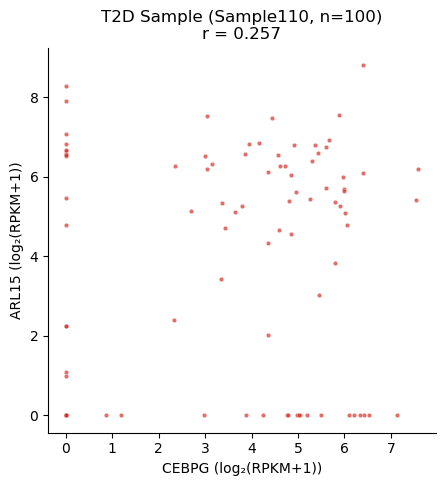

In [29]:
# D: Expression (T2D donor)
fig, ax = plt.subplots(figsize=(5, 5))

expr_a_t2d = _get_expr(largest_t2d_donor, gene_a)
expr_b_t2d = _get_expr(largest_t2d_donor, gene_b)
r_expr_t2d, _ = pearsonr(expr_a_t2d, expr_b_t2d)
sns.scatterplot(x=expr_a_t2d, y=expr_b_t2d, alpha=0.7, s=10, color='#d73027')
ax.set_xlabel(f'{gene_a} (log₂(RPKM+1))')
ax.set_ylabel(f'{gene_b} (log₂(RPKM+1))')
ax.set_title(f'T2D Sample ({largest_t2d_donor}, n={largest_t2d_n})\nr = {r_expr_t2d:.3f}')
ax.spines[['top', 'right']].set_visible(False)

plt.savefig('Figure2/t2d_expr.png', dpi=200, bbox_inches='tight')
plt.savefig('Figure2/t2d_expr.svg', bbox_inches='tight')

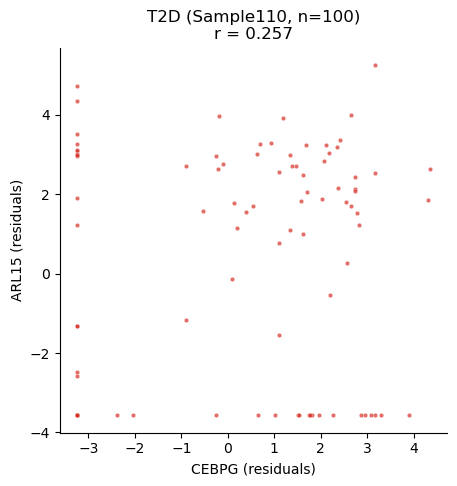

In [30]:
# E: Residuals (T2D donor)
fig, ax = plt.subplots(figsize=(5, 5))
r_resid_t2d, _ = pearsonr(x_t2d_donor, y_t2d_donor)
sns.scatterplot(x=x_t2d_donor, y=y_t2d_donor, alpha=0.7, s=10, color='#d73027')
ax.set_xlabel(f'{gene_a} (residuals)')
ax.set_ylabel(f'{gene_b} (residuals)')
ax.set_title(f'T2D ({largest_t2d_donor}, n={largest_t2d_n})\nr = {r_resid_t2d:.3f}')
ax.spines[['top', 'right']].set_visible(False)

plt.savefig('Figure2/t2d_residuals.png', dpi=200, bbox_inches='tight')
plt.savefig('Figure2/t2d_residuals.svg', bbox_inches='tight')

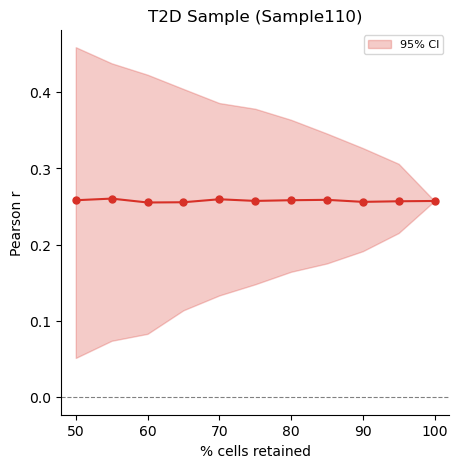

In [31]:
# F: Subsampling (T2D donor)
fig, ax = plt.subplots(figsize=(5, 5))
ax.fill_between(sub_t2d_df['frac'] * 100, sub_t2d_df['q025'], sub_t2d_df['q975'],
                alpha=0.25, color='#d73027', label='95% CI')
ax.plot(sub_t2d_df['frac'] * 100, sub_t2d_df['mean_r'], 'o-', color='#d73027', markersize=5)
ax.axhline(0, color='gray', lw=0.8, ls='--')
ax.set_xlabel('% cells retained')
ax.set_ylabel('Pearson r')
ax.set_title(f'T2D Sample ({largest_t2d_donor})')
ax.legend(fontsize=8)
ax.set_xlim(48, 102)
ax.spines[['top', 'right']].set_visible(False)

plt.savefig('Figure2/t2d_resampling.png', dpi=200, bbox_inches='tight')
plt.savefig('Figure2/t2d_resampling.svg', bbox_inches='tight')

In [33]:
# Auto-assign colors
disease_values = donor_corr_df['Disease'].unique()
colors = {}
for val in disease_values:
    if 'T2D' in str(val) or 'diabetes' in str(val).lower():
        colors[val] = '#d73027'
    else:
        colors[val] = '#4575b4'

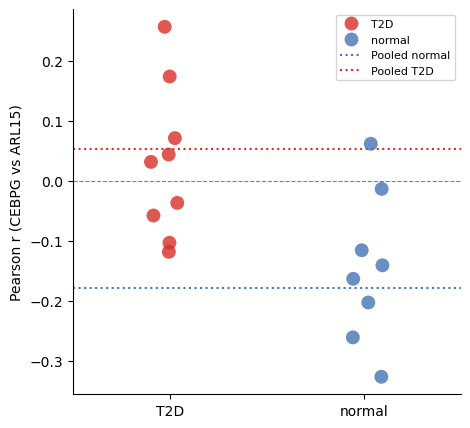

In [41]:

# ── G: Per-donor correlations as strip, grouped by condition ──
fig, ax = plt.subplots(figsize=(5, 5))
sns.stripplot(data=donor_corr_df, x='Disease', y='r', hue='Disease', ax=ax, 
              palette=colors, size=10, jitter=0.1, alpha=0.8, legend=True)
ax.axhline(0, color='gray', lw=0.8, ls='--')
ax.axhline(sig_edges.iloc[idx]['r_ctrl'], color='#4575b4', lw=1.5, ls=':', label='Pooled normal')
ax.axhline(sig_edges.iloc[idx]['r_t2d'], color='#d73027', lw=1.5, ls=':', label='Pooled T2D')
ax.set_xlabel('')
ax.set_ylabel(f'Pearson r ({gene_a} vs {gene_b})')
#ax.set_title('G   Per-donor vs pooled correlation')
ax.legend(fontsize=8, loc='best')
ax.spines[['top', 'right']].set_visible(False)

plt.savefig('Figure2/per_donor_r.png', dpi=200, bbox_inches='tight')
plt.savefig('Figure2/per_donor_r.svg', bbox_inches='tight')

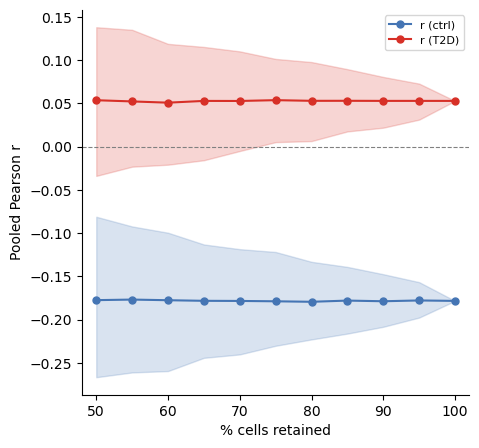

In [43]:
# ── H: Pooled cell subsampling — r_ctrl and r_t2d ──
fig, ax = plt.subplots(figsize=(5, 5))
frac_values = sorted(pooled_sub_df['frac'].unique())

ctrl_means, ctrl_lo, ctrl_hi = [], [], []
t2d_means, t2d_lo, t2d_hi = [], [], []
for fv in frac_values:
    subset = pooled_sub_df[pooled_sub_df['frac'] == fv]
    ctrl_means.append(subset['r_ctrl'].mean())
    ctrl_lo.append(subset['r_ctrl'].quantile(0.025))
    ctrl_hi.append(subset['r_ctrl'].quantile(0.975))
    t2d_means.append(subset['r_t2d'].mean())
    t2d_lo.append(subset['r_t2d'].quantile(0.025))
    t2d_hi.append(subset['r_t2d'].quantile(0.975))

frac_pct = [f * 100 for f in frac_values]
ax.fill_between(frac_pct, ctrl_lo, ctrl_hi, alpha=0.2, color='#4575b4')
ax.plot(frac_pct, ctrl_means, 'o-', color='#4575b4', markersize=5, label='r (ctrl)')
ax.fill_between(frac_pct, t2d_lo, t2d_hi, alpha=0.2, color='#d73027')
ax.plot(frac_pct, t2d_means, 'o-', color='#d73027', markersize=5, label='r (T2D)')
ax.axhline(0, color='gray', lw=0.8, ls='--')
ax.set_xlabel('% cells retained')
ax.set_ylabel('Pooled Pearson r')
#ax.set_title('Subsampling stability (pooled per group)')
ax.set_xlim(48, 102)
ax.legend(fontsize=8)
ax.spines[['top', 'right']].set_visible(False)

plt.savefig('Figure2/pooled_subsampling.png', dpi=200, bbox_inches='tight')
plt.savefig('Figure2/pooled_subsampling.svg', bbox_inches='tight')

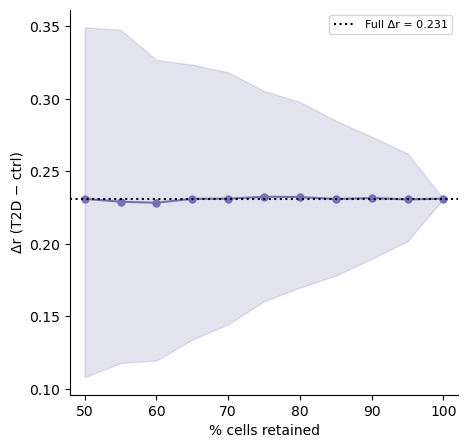

In [44]:

# ── I: Pooled cell subsampling — Δr ──
fig, ax = plt.subplots(figsize=(5, 5))
dr_means, dr_lo, dr_hi = [], [], []
for fv in frac_values:
    subset = pooled_sub_df[pooled_sub_df['frac'] == fv]
    dr_means.append(subset['delta_r'].mean())
    dr_lo.append(subset['delta_r'].quantile(0.025))
    dr_hi.append(subset['delta_r'].quantile(0.975))

ax.fill_between(frac_pct, dr_lo, dr_hi, alpha=0.2, color='#7570b3')
ax.plot(frac_pct, dr_means, 'o-', color='#7570b3', markersize=5)
#ax.axhline(0, color='gray', lw=0.8, ls='--')
ax.axhline(sig_edges.iloc[idx]['delta_r'], color='black', lw=1.5, ls=':', 
           label=f'Full Δr = {sig_edges.iloc[idx]["delta_r"]:.3f}')
ax.set_xlabel('% cells retained')
ax.set_ylabel('Δr (T2D − ctrl)')
#ax.set_title('I   Stability of Δr (pooled per group)')
ax.set_xlim(48, 102)
ax.legend(fontsize=8)
ax.spines[['top', 'right']].set_visible(False)



plt.savefig('Figure2/pooled_delta.png', dpi=200, bbox_inches='tight')
plt.savefig('Figure2/pooled_delta.svg', bbox_inches='tight')

In [ ]:

# ─────────────────────────────────────────────────────────────────────────────
# 6. PLOTS
# ─────────────────────────────────────────────────────────────────────────────



from matplotlib.lines import Line2D

fig, axes = plt.subplots(3, 3, figsize=(16, 14))
fig.suptitle(f'Example gene pair: {gene_a} — {gene_b}\n'
             f'r_ctrl = {sig_edges.iloc[idx]["r_ctrl"]:.3f}, '
             f'r_T2D = {sig_edges.iloc[idx]["r_t2d"]:.3f}, '
             f'Δr = {sig_edges.iloc[idx]["delta_r"]:.3f}', fontsize=12)



# ══════════════════════════════════════════════════════════════════════════════
# ROW 1: Largest control donor
# ══════════════════════════════════════════════════════════════════════════════

# A: Expression (ctrl donor)
ax = axes[0, 0]
expr_a_ctrl = _get_expr(largest_ctrl_donor, gene_a)
expr_b_ctrl = _get_expr(largest_ctrl_donor, gene_b)
r_expr_ctrl, _ = pearsonr(expr_a_ctrl, expr_b_ctrl)
ax.scatter(expr_a_ctrl, expr_b_ctrl, alpha=0.3, s=10, color='#4575b4')
ax.set_xlabel(f'{gene_a} (log₂(RPKM+1))')
ax.set_ylabel(f'{gene_b} (log₂(RPKM+1))')
ax.set_title(f'A   Expression — ctrl ({largest_ctrl_donor}, n={largest_ctrl_n})\nr = {r_expr_ctrl:.3f}')
ax.spines[['top', 'right']].set_visible(False)

# B: Residuals (ctrl donor)
ax = axes[0, 1]
r_resid_ctrl, _ = pearsonr(x_ctrl_donor, y_ctrl_donor)
ax.scatter(x_ctrl_donor, y_ctrl_donor, alpha=0.3, s=10, color='#4575b4')
ax.set_xlabel(f'{gene_a} (residuals)')
ax.set_ylabel(f'{gene_b} (residuals)')
ax.set_title(f'B   Residuals — ctrl ({largest_ctrl_donor}, n={largest_ctrl_n})\nr = {r_resid_ctrl:.3f}')
ax.spines[['top', 'right']].set_visible(False)

# C: Subsampling (ctrl donor)
ax = axes[0, 2]
ax.fill_between(sub_ctrl_df['frac'] * 100, sub_ctrl_df['q025'], sub_ctrl_df['q975'],
                alpha=0.25, color='#4575b4', label='95% CI')
ax.plot(sub_ctrl_df['frac'] * 100, sub_ctrl_df['mean_r'], 'o-', color='#4575b4', markersize=5)
ax.axhline(0, color='gray', lw=0.8, ls='--')
ax.set_xlabel('% cells retained')
ax.set_ylabel('Pearson r')
ax.set_title(f'C   Subsampling stability — ctrl ({largest_ctrl_donor})')
ax.legend(fontsize=8)
ax.set_xlim(48, 102)
ax.spines[['top', 'right']].set_visible(False)

# ══════════════════════════════════════════════════════════════════════════════
# ROW 2: Largest T2D donor
# ══════════════════════════════════════════════════════════════════════════════

# D: Expression (T2D donor)
ax = axes[1, 0]
expr_a_t2d = _get_expr(largest_t2d_donor, gene_a)
expr_b_t2d = _get_expr(largest_t2d_donor, gene_b)
r_expr_t2d, _ = pearsonr(expr_a_t2d, expr_b_t2d)
ax.scatter(expr_a_t2d, expr_b_t2d, alpha=0.3, s=10, color='#d73027')
ax.set_xlabel(f'{gene_a} (log₂(RPKM+1))')
ax.set_ylabel(f'{gene_b} (log₂(RPKM+1))')
ax.set_title(f'D   Expression — T2D ({largest_t2d_donor}, n={largest_t2d_n})\nr = {r_expr_t2d:.3f}')
ax.spines[['top', 'right']].set_visible(False)

# E: Residuals (T2D donor)
ax = axes[1, 1]
r_resid_t2d, _ = pearsonr(x_t2d_donor, y_t2d_donor)
ax.scatter(x_t2d_donor, y_t2d_donor, alpha=0.3, s=10, color='#d73027')
ax.set_xlabel(f'{gene_a} (residuals)')
ax.set_ylabel(f'{gene_b} (residuals)')
ax.set_title(f'E   Residuals — T2D ({largest_t2d_donor}, n={largest_t2d_n})\nr = {r_resid_t2d:.3f}')
ax.spines[['top', 'right']].set_visible(False)

# F: Subsampling (T2D donor)
ax = axes[1, 2]
ax.fill_between(sub_t2d_df['frac'] * 100, sub_t2d_df['q025'], sub_t2d_df['q975'],
                alpha=0.25, color='#d73027', label='95% CI')
ax.plot(sub_t2d_df['frac'] * 100, sub_t2d_df['mean_r'], 'o-', color='#d73027', markersize=5)
ax.axhline(0, color='gray', lw=0.8, ls='--')
ax.set_xlabel('% cells retained')
ax.set_ylabel('Pearson r')
ax.set_title(f'F   Subsampling stability — T2D ({largest_t2d_donor})')
ax.legend(fontsize=8)
ax.set_xlim(48, 102)
ax.spines[['top', 'right']].set_visible(False)

# ══════════════════════════════════════════════════════════════════════════════
# ROW 3: All donors — strip plot, pooled subsampling, Δr stability
# ══════════════════════════════════════════════════════════════════════════════

# ── G: Per-donor correlations as strip, grouped by condition ──
ax = axes[2, 0]
sns.stripplot(data=donor_corr_df, x='Disease', y='r', hue='Disease', ax=ax, 
              palette=colors, size=10, jitter=0.1, alpha=0.8, legend=False)
ax.axhline(0, color='gray', lw=0.8, ls='--')
ax.axhline(sig_edges.iloc[idx]['r_ctrl'], color='#4575b4', lw=1.5, ls=':', label='Pooled r (ctrl)')
ax.axhline(sig_edges.iloc[idx]['r_t2d'], color='#d73027', lw=1.5, ls=':', label='Pooled r (T2D)')
ax.set_xlabel('')
ax.set_ylabel(f'Pearson r ({gene_a} vs {gene_b})')
ax.set_title('G   Per-donor vs pooled correlation')
ax.legend(fontsize=8, loc='best')
ax.spines[['top', 'right']].set_visible(False)

# ── H: Pooled cell subsampling — r_ctrl and r_t2d ──
ax = axes[2, 1]
frac_values = sorted(pooled_sub_df['frac'].unique())

ctrl_means, ctrl_lo, ctrl_hi = [], [], []
t2d_means, t2d_lo, t2d_hi = [], [], []
for fv in frac_values:
    subset = pooled_sub_df[pooled_sub_df['frac'] == fv]
    ctrl_means.append(subset['r_ctrl'].mean())
    ctrl_lo.append(subset['r_ctrl'].quantile(0.025))
    ctrl_hi.append(subset['r_ctrl'].quantile(0.975))
    t2d_means.append(subset['r_t2d'].mean())
    t2d_lo.append(subset['r_t2d'].quantile(0.025))
    t2d_hi.append(subset['r_t2d'].quantile(0.975))

frac_pct = [f * 100 for f in frac_values]
ax.fill_between(frac_pct, ctrl_lo, ctrl_hi, alpha=0.2, color='#4575b4')
ax.plot(frac_pct, ctrl_means, 'o-', color='#4575b4', markersize=5, label='r (ctrl)')
ax.fill_between(frac_pct, t2d_lo, t2d_hi, alpha=0.2, color='#d73027')
ax.plot(frac_pct, t2d_means, 'o-', color='#d73027', markersize=5, label='r (T2D)')
ax.axhline(0, color='gray', lw=0.8, ls='--')
ax.set_xlabel('% cells retained')
ax.set_ylabel('Pooled Pearson r')
ax.set_title('H   Subsampling stability (pooled per group)')
ax.set_xlim(48, 102)
ax.legend(fontsize=8)
ax.spines[['top', 'right']].set_visible(False)

# ── I: Pooled cell subsampling — Δr ──
ax = axes[2, 2]
dr_means, dr_lo, dr_hi = [], [], []
for fv in frac_values:
    subset = pooled_sub_df[pooled_sub_df['frac'] == fv]
    dr_means.append(subset['delta_r'].mean())
    dr_lo.append(subset['delta_r'].quantile(0.025))
    dr_hi.append(subset['delta_r'].quantile(0.975))

ax.fill_between(frac_pct, dr_lo, dr_hi, alpha=0.2, color='#7570b3')
ax.plot(frac_pct, dr_means, 'o-', color='#7570b3', markersize=5)
ax.axhline(0, color='gray', lw=0.8, ls='--')
ax.axhline(sig_edges.iloc[idx]['delta_r'], color='black', lw=1.5, ls=':', 
           label=f'Full Δr = {sig_edges.iloc[idx]["delta_r"]:.3f}')
ax.set_xlabel('% cells retained')
ax.set_ylabel('Δr (T2D − ctrl)')
ax.set_title('I   Stability of Δr (pooled per group)')
ax.set_xlim(48, 102)
ax.legend(fontsize=8)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('example_gene_pair.png', dpi=200, bbox_inches='tight')
plt.savefig('example_gene_pair.svg', bbox_inches='tight')
print(f"\nSaved example_gene_pair.png/.pdf")
plt.show()

In [ ]:
sig_edges.iloc[idx]